### Tracing сообщений при помощи LangFuse

# Import libs

In [1]:
import os

# User Data Test
import secrets

# Работаем с секретами
from dotenv import load_dotenv
from langchain_community.embeddings.yandex import YandexGPTEmbeddings
from langchain_openai import ChatOpenAI

# Работа с LangFuse
from langfuse import Langfuse
from langfuse.callback import CallbackHandler
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Кастомные классы тут
from agents.profkom_consultant import AgentStatus, UnionAgent, build_builder
from modules.chroma_ext import ChromaAdapter
from modules.redis_ext import RedisAdapter

# Define global args

In [3]:
load_dotenv("../../.env")
openai_api_key = os.getenv("API_KEY")
FOLDER_ID = os.getenv("FOLDER_ID")
openai_api_base = "https://llm.api.cloud.yandex.net/v1"
model = f"gpt://{FOLDER_ID}/yandexgpt"

#### Define Semantic Cache logic

In [4]:
embeddings = YandexGPTEmbeddings(folder_id=os.getenv("FOLDER_ID"), iam_token=os.getenv("API_KEY"))

In [5]:
storage = RedisAdapter(embeddings)

2026-02-07 18:13:45 | INFO | modules.redis_ext.base | pid=12789 | base.py:17 | Redis url: redis://127.0.0.1:6379
2026-02-07 18:13:45 | INFO | modules.redis_ext.base | pid=12789 | base.py:25 | REDIS_THRESHOLD: 0.05
2026-02-07 18:13:45 | INFO | modules.redis_ext.base | pid=12789 | base.py:26 | REDIS_TTL: 3600.0


#### Define Langfuse

In [6]:
langfuse = Langfuse(
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    host=os.getenv("LANGFUSE_HOST"),
)

In [7]:
langfuse.auth_check()

True

#### Define chroma

In [8]:
db = ChromaAdapter(similarity_filter=1.5, **{"API_KEY": openai_api_key, "FOLDER_ID": FOLDER_ID, "CHROMA_MAX_RAG_DOCUMENTS": 30})

2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.reranker | pid=12789 | reranker.py:12 | Initializing BM25Reranker with gpt-3.5-turbo
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:31 | CHROMA_API_KEY: AQVN**h9wc
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:33 | CHROMA_API_URL: https://llm.api.cloud.yandex.net:443/foundationModels/v1/textEmbedding
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:35 | CHROMA_FOLDER_ID: b1g2**508m
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:38 | CHROMA_HOST: 127.0.0.1
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:41 | CHROMA_PORT: 8000
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:44 | CHROMA_TOPK: 5
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:47 | CHROMA_MAX_RAG: 30
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:50 | sim

In [9]:
data = db.get_info(query="Структура профкома", collection_name="PRODUCTION_PROFKOM")

2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:115 | called Структура профкома in get_info for PRODUCTION_PROFKOM
2026-02-07 18:13:47 | INFO | modules.chroma_ext.base | pid=12789 | base.py:68 | embedding_function call
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:36 | api_url: https://llm.api.cloud.yandex.net:443/foundationModels/v1/textEmbedding
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:39 | iam_token: b1g2***508m
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:43 | iam_token: AQVN***h9wc
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:47 | time_sleep: 0.01
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:58 | text_type: query
2026-02-07 18:13:47 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:63 | doc_model_uri: emb

# Define LLM

In [10]:
llm = ChatOpenAI(
    model=model,
    temperature=0.1,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key,
)

In [11]:
agent = UnionAgent(llms={"default": llm}, cache=storage, langfuse_client=langfuse, chroma_client=db)

2026-02-07 18:13:49 | INFO | agents.profkom_consultant.nodes.core | pid=12789 | core.py:26 | Initializing agents.profkom_consultant.nodes.core
2026-02-07 18:13:49 | INFO | agents.profkom_consultant.nodes.core | pid=12789 | core.py:28 | LLM keys dict_keys(['default'])
2026-02-07 18:13:49 | INFO | agents.profkom_consultant.nodes.core | pid=12789 | core.py:37 | HISTORY_LIMIT: 10
2026-02-07 18:13:49 | INFO | agents.profkom_consultant.nodes.core | pid=12789 | core.py:38 | COLLECTION_NAME: PRODUCTION_PROFKOM


# Build Graph

In [12]:
union_agent = build_builder(agent=agent, checkpointer=MemorySaver())

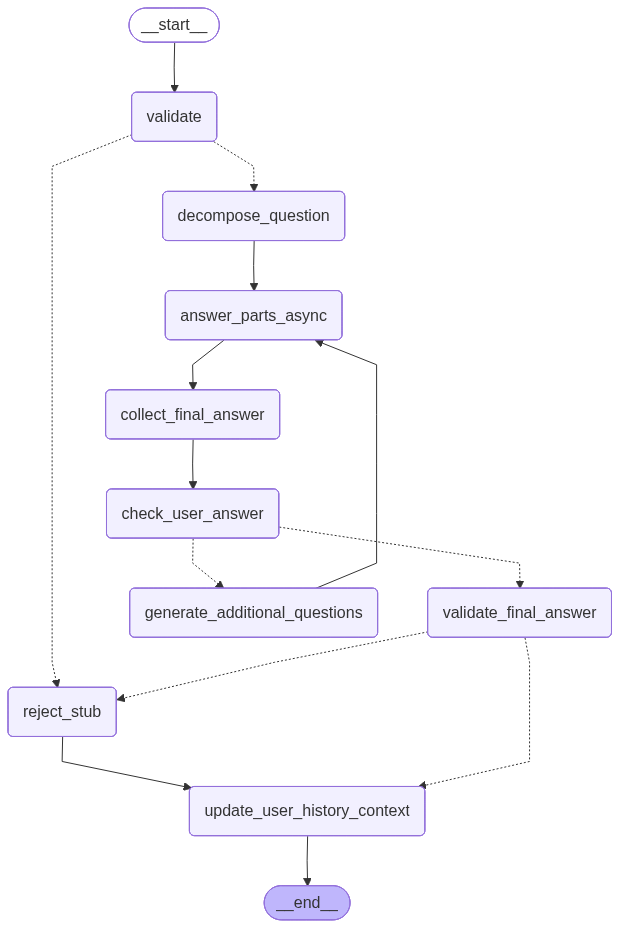

In [13]:
union_agent

# Add LangFuse

https://langfuse.com/integrations/frameworks/langchain

По умолчанию надо будет с версии 3.12.0 использовать новый API + все в ENV

    LANGFUSE_SECRET_KEY = "sk-lf-..."
    LANGFUSE_PUBLIC_KEY = "pk-lf-..."
    LANGFUSE_BASE_URL = "https://cloud.langfuse.com" # 🇪🇺 EU region

## Add Agent Calling

In [14]:
langfuse_handler = CallbackHandler(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    host=os.getenv("LANGFUSE_HOST"),
    trace_name="langchain-dev",
)

In [24]:
start_state = {
    "user_id": "test-user-sasha-" + str(26),
    "text": " ППО Невинномысский Азот | А кто председатель первого или 2 цеха?",
    "status": AgentStatus.ACTIVE,
}

In [25]:
user_id = start_state.get("user_id")
session_id = secrets.token_urlsafe(64)

result = await union_agent.ainvoke(
    start_state,
    config={
        "configurable": {"thread_id": user_id},
        "callbacks": [langfuse_handler],
        "metadata": {
            "stage": "dev",
            "langfuse_session_id": session_id,
            "langfuse_user_id": user_id,
        },
    },
)
print("\n")
print("\n")
print(result.get("final_answer"))

2026-02-07 18:16:36 | INFO | modules.redis_ext.base | pid=12789 | base.py:45 | getting query
2026-02-07 18:16:37 | INFO | modules.redis_ext.base | pid=12789 | base.py:33 | saving query
2026-02-07 18:16:37 | INFO | modules.redis_ext.base | pid=12789 | base.py:45 | getting query
2026-02-07 18:16:38 | INFO | modules.redis_ext.base | pid=12789 | base.py:33 | saving query
2026-02-07 18:16:38 | INFO | modules.redis_ext.base | pid=12789 | base.py:45 | getting query
2026-02-07 18:16:38 | INFO | modules.redis_ext.base | pid=12789 | base.py:45 | getting query
2026-02-07 18:16:38 | INFO | modules.chroma_ext.base | pid=12789 | base.py:115 | called Кто является председателем первого цеха ППО «Невинномысский Азот»? in get_info for PRODUCTION_PROFKOM
2026-02-07 18:16:38 | INFO | modules.chroma_ext.base | pid=12789 | base.py:68 | embedding_function call
2026-02-07 18:16:38 | INFO | modules.chroma_ext.utils.embedings | pid=12789 | embedings.py:80 | called _get_single_embedding
2026-02-07 18:16:38 | INF

In [27]:
result

{'user_id': 'test-user-sasha-26',
 'user_history': [' ППО Невинномысский Азот | Какие документы необходимы для получения материальной помощи от ППО «Невинномысский Азот»?',
  ' ППО Невинномысский Азот | Расскажи подробнее об этом процессе?',
  ' ППО Невинномысский Азот | А кто председатель первого или 2 цеха?'],
 'model_answers': ['Чтобы получить материальную помощь от ППО «Невинномысский Азот», нужно подать заявление председателю цехового комитета. К заявлению приложите подтверждающие документы: копии документов, которые подтверждают степень родства, факт смерти или рождения члена семьи, состав семьи и сведения о доходах. Могут понадобиться и другие документы — это зависит от ситуации.',
  'Чтобы получить материальную помощь от ППО «Невинномысский Азот», нужно подать заявление председателю цехового комитета. К заявлению приложите подтверждающие документы. Это могут быть копии документов, которые подтверждают степень родства, факт смерти или рождения члена семьи, состав семьи и сведени